In [1]:
#  lines,  3 solved,  12 passed_some_traininputs, 5 passed_all_traininputs, 87 undeduced: 
# evaluation
# just for the snapshot purpose. No inspection as of why and how other than just knowing
# mechanisms of solved cases.

# Fabulous performance highlighting soundedness of current approach and demanding
# revisiting the tokenization protocols and clearing out all the dust

# The current notebook may have some errors but it indicates the following:
# 1) the cuttent solver runs on evaluation without any error
# 2) the current solver seems to discerns into more tasks based on the apply scenarios
# 3) the current solver seems to struggle with nuances in tokenization and objective work

from inductive_core_knowledge import * 

In [2]:
def print_arrays(case_num):
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [3]:
from pathlib import Path
data_path = Path("/home/hshallal/Desktop/ARCsolver/data/")
training_path = data_path / 'evaluation'
tt = load_set(training_path)
known = load_serialized('assets/solved_indices_for_the_day.pkl')

/home/hshallal/Desktop/ARCsolver/utils.py:496: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  target_indices = (np.argwhere(in_ == x[0]), np.argwhere(out_ == x[1]))


148
[['is_exp_cont', [2.0, 2.0]]]


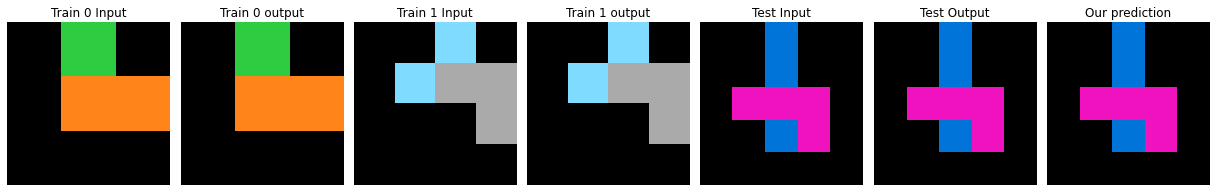

====
161
[['is_exp_cont', [0.5, 0.5]]]


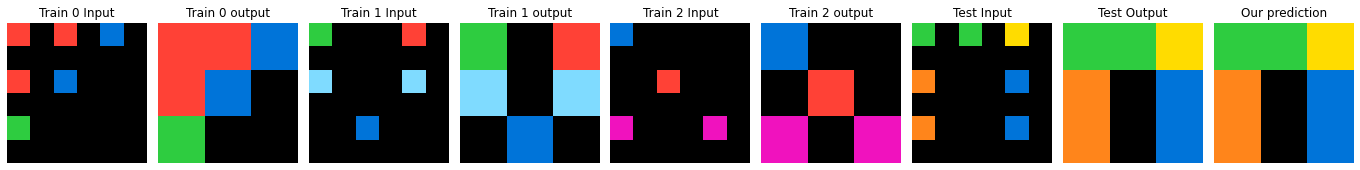

====
370
[<function apply_scenarios at 0x7f018f3da3a0>]


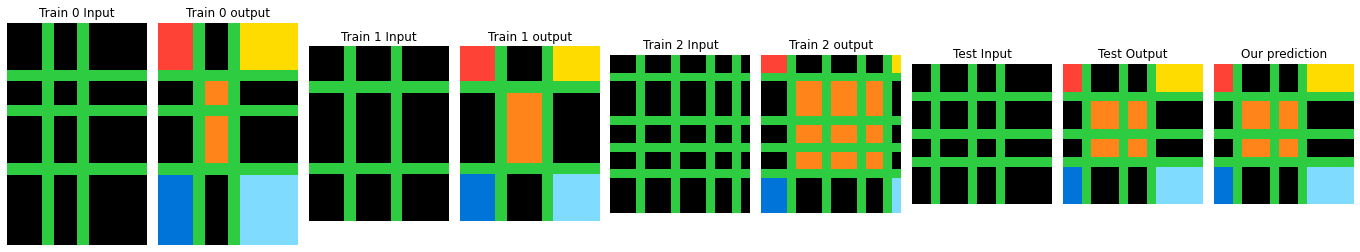

====


TypeError: argument of type 'PosixPath' is not iterable

In [4]:
from timeit import default_timer as timer
start = timer()
today_analysis = []
for n in range(len(tt)):
    this_task = Inductive(tt[n])
    today_analysis.append(this_task)
    if this_task.solved == 'solved':
        print(n)
        print(this_task.mechanisms)
        plot_task_eval(tt[n], [x.astype('int64') for x in this_task.test_situation])
        print('====')
    
if 'evaluation' in training_path:
    serialize(today_analysis, 'assets/evaluation_today_analysis')
else:
    serialize(today_analysis, 'assets/training_today_analysis')
    
end = timer()
print("It took this number of seconds: ", end - start)
print(len(today_analysis))
# It took this number of seconds: 1015

In [5]:
serialize(today_analysis, 'assets/evaluation_today_analysis')

In [6]:
previous_analysis = load_serialized('assets/evaluation_today_analysis')
#previous_screening_results = load_serialized('assets/screening_results')

In [ ]:
for n in known:
    if previous_analysis[n].solved != 'solved':
        print(n)
        plot_task(tt[n])
        print('====')

In [8]:
current_attention = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective and this_task.dimension_status == 'deduced' and this_task.solved != 'solved':
        current_attention.append(n)
        
print(len(current_attention))

67


In [9]:
coding_situation = {}
coding_situation[-1] = []
coding_situation[0] = []
coding_situation[1] = []


for n in range(len(previous_analysis)):
    this_task = previous_analysis[n]
    if this_task.objective_status == 'irr':
        coding_situation[-1].append(n)
    elif this_task.objective_status == 'obd':
        coding_situation[0].append(n)
    elif this_task.objective_status == 'red':
        coding_situation[1].append(n)

        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))



def screen_all(previous_analysis):
    results = deepcopy(results_dict)
    
    for task in range(len(previous_analysis)):
        #print(task)
        this_task = deepcopy(previous_analysis[task])
        current_situation, train_situation, train_screen, test_situation, test_screen = this_task.current_situation, this_task.train_situation, this_task.train_screen, this_task.test_situation, this_task.test_screen
        
        if current_situation in results_dict.keys():
            results[current_situation].append(task)
        else:
            results['unknown'].append((task, current_situation))

    for k, v in results.items():
        print(k, ' : ', len(v))
    
    return results

screening_results = screen_all(previous_analysis)
# print(this_task.apply_routine_list)
    

# training: 310 deduces: 0.775
# -1  :  64 # irr
# 0  :  245 # obd
# 1  :  91 # red 

# training: 310 deduces: 0.775
# -1  :  92 # irr
# 0  :  210
# 1  :  98 # red 

-1  :  92
0  :  210
1  :  98


NameError: name 'results_dict' is not defined

In [38]:
all_undeduced = 0
for n in previous_analysis:
    if n.dimension_status != 'deduced':
        all_undeduced += 1
all_undeduced

87

In [11]:
# print(this_task.apply_routine_list)
screening_results = {}
solved = 0
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.solved == 'solved':
        solved += 1
    overall = [x[2] for x in this_task.apply_routine_list]
    imp = [x for x in overall if x != 'ineligible']
    for m in overall:
        if m != 'ineligible':
            if m not in screening_results.keys():
                screening_results[m] = []
            screening_results[m].append(n)
            
serialize(screening_results, 'assets/evaluation_screening_results')

    
for k, v in screening_results.items():
    print(k, ' : ', len(v))
    
print(solved)

# passed_all_testinputs  :  32
# passed_some_traininputs  :  11
# unpassed_all_testinputs  :  8
# 36


passed_some_traininputs  :  12
unpassed_all_testinputs  :  5
passed_all_testinputs  :  1
3


In [14]:
screening_results

{'passed_some_traininputs': [1,
  15,
  25,
  81,
  106,
  168,
  190,
  211,
  302,
  320,
  373,
  394],
 'unpassed_all_testinputs': [1, 51, 169, 338, 364],
 'passed_all_testinputs': [370]}

In [35]:
#tt[1]
previous_analysis[364].test_situation

[array([[7, 7, 0, 0, 0, 7, 7, 7, 0, 0, 0, 7, 0, 0, 7, 7, 0, 7, 0, 7, 7],
        [7, 0, 7, 7, 7, 0, 0, 0, 0, 7, 7, 7, 7, 7, 7, 0, 0, 7, 7, 0, 0],
        [7, 7, 7, 7, 7, 0, 7, 0, 0, 7, 7, 7, 7, 7, 0, 0, 7, 7, 7, 7, 0],
        [7, 0, 0, 7, 0, 7, 7, 7, 0, 0, 7, 0, 0, 0, 0, 7, 0, 0, 7, 7, 0],
        [7, 7, 7, 7, 0, 7, 7, 0, 7, 0, 7, 7, 7, 7, 0, 7, 7, 7, 7, 7, 7],
        [7, 7, 0, 7, 7, 7, 7, 0, 7, 7, 7, 7, 7, 0, 7, 7, 7, 7, 7, 7, 7],
        [0, 7, 7, 7, 0, 0, 7, 7, 7, 7, 0, 0, 7, 0, 0, 7, 7, 7, 7, 7, 7],
        [7, 0, 0, 7, 0, 0, 7, 7, 7, 7, 0, 7, 0, 7, 7, 7, 7, 0, 7, 7, 7],
        [7, 7, 7, 0, 7, 0, 7, 7, 7, 0, 7, 7, 7, 7, 7, 7, 7, 0, 0, 0, 7],
        [7, 7, 7, 0, 7, 7, 7, 7, 0, 7, 0, 7, 7, 7, 7, 7, 0, 7, 7, 7, 7],
        [0, 7, 7, 0, 7, 0, 7, 0, 0, 7, 7, 7, 7, 7, 0, 7, 0, 0, 0, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 0, 7, 0, 7, 7, 7, 7, 7, 7, 0, 0, 0],
        [7, 7, 0, 0, 0, 7, 7, 0, 7, 7, 0, 0, 0, 0, 0, 0, 0, 7, 0, 7, 7],
        [0, 7, 7, 0, 0, 7, 0, 0, 7, 7, 0, 8, 8, 8, 

In [36]:
previous_analysis[364].test_token_to_colors

[{'nonbg-1pr': 0, 'nonbg0pr': 8}]

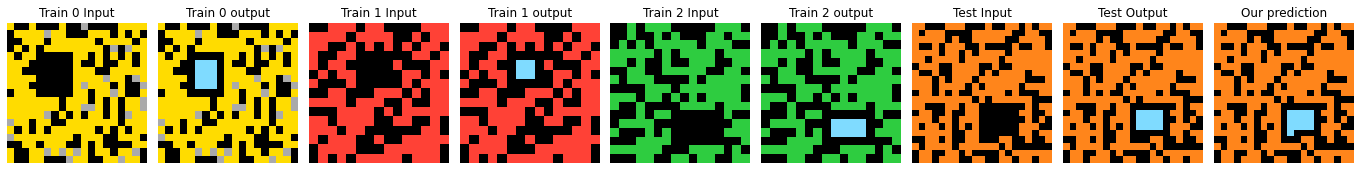

In [37]:
plot_task_eval(tt[364], [x.astype('int64') for x in previous_analysis[364].test_situation])

In [12]:
for n in screening_results['unpassed_all_testinputs']:
    print(n)
    plot_task_eval(tt[n], [x.astype('int64') for x in previous_analysis[n].test_situation])
    print('global_objective:', previous_analysis[n].global_objective)
    print('pr_kn_apply_scenarios:', previous_analysis[n].pr_kn_apply_scenarios)
    print('======')

1


ValueError: invalid literal for int() with base 10: 'nonbg2'

In [13]:
for n in screening_results['passed_some_traininputs']:
    print(n)
    plot_task_eval(tt[n], [x.astype('int64') for x in previous_analysis[n].test_situation])
    print('global_objective:', previous_analysis[n].global_objective)
    print('pr_kn_apply_scenarios:', previous_analysis[n].pr_kn_apply_scenarios)
    print('======')

1


ValueError: invalid literal for int() with base 10: 'nonbg2'

In [ ]:
def demonstrate_heuristic_candidacy(n):
    print(n)
    plot_task(tt[n])
    this_task = previous_analysis[n]
    print('Situation: ', [x[2] for x in this_task.apply_routine_list])
    print(this_task.objective_status, this_task.running_objective, this_task.global_objective)
    print(this_task.train_screen, this_task.test_screen)
    print(this_task.token_to_colors, this_task.test_token_to_colors, )
    print(this_task.pr_kn_apply_scenarios)
    print('=====')

In [ ]:
# case 343: the global objective didn't pick up on the other more elaborate objectives
# [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg2pr', 'direct')]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [2, 3, 6], (2, {3}, {1, 4}), (3, {5}, {1, 3}), (6, {1}, {2, 3})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [2, 3, 6], (2, {5}, {1, 3}), (3, {3}, {1, 2}), (6, {1}, {2})]]
# case 228: tokenization of test didn't spare an int anchor which is be default
# is the one spared of tokenization, in the test case, this did't happen,
# this is a tokenization issue. In addition, the solution is already in the prior knowledge
# it is just that the system blindly tokenized the whole test without sparing the most
# frequent indicated by 2 in the sorted frequency graph!
# case 292 is an objective issue due to the independent tokenization, global objective must
# have collected other issues
# check_heuristics: is_single_output, pass_info: is bg in outputs, bg
#                   99: output two same frequency nonbg
#                   338: exclude bg
# apply_heuristcs: 1) check multiple nonbg if you have <= three options along with the passed_info
#                  2) include other heuristics
heuristic_cases = [343, 228, 292]
for n in heuristic_cases:
    demonstrate_heuristic_candidacy(Inductive(tt[n]))

In [ ]:
for n in screening_results['passed_some_traininputs']:
    print(n)
    plot_task(tt[n])
    print('=======')

In [ ]:
to_get_now = [48, 54, 72, 94, 96, 97, 119, 124, 186, 250, 251, 291, 292, 293, 316, 328, 337, 372]
more_prior_knowledge = [47, 66, 82, 105, 115, 129, 141, 142, 151, 136, 171, 193, 228, 248, 270, 310, 325, 354, 392]

len(to_get_now), len(more_prior_knowledge)

In [ ]:
knowns = load_serialized('assets/solved_indices_for_the_day.pkl')

In [ ]:
to_hook_up = [1, 345, 97, 119, 186, 250, 293, 337]
to_figure_out = [345, 48, 66, 105, 129, 151, 217, 290]

In [ ]:
# new
for n in current_attention:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('pr_kn_apply_scenarios: ', this_task.pr_kn_apply_scenarios)
    print('=========')

In [ ]:
for n in [99, 128, 338] + [266, 388] + to_get_now:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('pr_kn_apply_scenarios: ', this_task.pr_kn_apply_scenarios)
    print('=========')

In [ ]:
# 55, 202, 297: needs revisiting tokenization, objectivication schemes

In [ ]:
more_prior_knowledge = [47, 66, 82, 105, 115, 129, 141, 142, 151, 136, 171, 193, 228, 248,
                       270, 310, 325, 354, 392]
# 129, 290, 343, 345: more neighbor based featurization
# 47: is_two_red_objects_connected_by_blue_path

# output is vertical sorted based on frequency
# 66: output left most third versus center of rightmost third
# 134, 325: output is top right/left 1/nth corner

# 115, 171, 310: output is 180 flip vertical-double
# 136, 248: output is 180 flip horizontal double
# 82, 105, 141, 151, 193: output is a 90 flip 4-multiple

# 142: find a similar object to the object in the grey corner, turn it into grey

# 228: spare most frequent and grey everything else

# 270: output the object with the most blue cells
# 354: color encompassing more blue cells


In [ ]:
dimension_solution_attention = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective and this_task.dimension_status != 'deduced' and this_task.solved != 'solved':
        dimension_solution_attention.append(n)

In [ ]:
len(dimension_solution_attention)

In [ ]:
for n in dimension_solution_attention:
    this_task = previous_analysis[n]
    print(n)
    plot_task(tt[n])
    print('global_objective: ', sorted(this_task.global_objective))
    print('=========')

In [ ]:
to_solve_now = [48]
to_get_dim_now = [21, 28, 30, 38, 56, 78, 108, 120, 176, 187, 206, 215, 289, 299, 309, 324, 333, 350, 375, 395]

# 21, 152, 252: coallesce/fir objects into solution
# 28: output bound by a box
# 30, 56, 383: output multiples (one or more) of the only object in a vertical or horizontal or diagonal or offdiagonal
# 35, 206: output the unique/outsider object
# 78: output the most freeequent object
# 299: output the biggest object
# 324: output and imension is related to the number of objects
# 87: output the object and extend till anchors
# 38, 187: output the top left quadrant of the object, top half
# 108: find the object and output 90 flip 4-times and change its color
# 110, 120: output an object neighbor to an anchor with or without including/modifying the anchor
# 133: output the object, remove noise, change the object color to the noise
# 176, 217, 289: output everything other than bg
# 215, 395: output the box with most red cells
# 241, 350, 399: output is a reflection over a symmetry line on a black block
# 309: output the bounding box and what's inside
# 333: output is coded with the only nonbg
# 375: mutiple vertical

In [ ]:
# tokenized_graph, in_, x_situation, y_situation, sorted_frequency_graph, edge_situation, neighbor_situation
#         0         1       2            3              4                     5                    6                

In [ ]:
# fix test_token_to_colors 44, 52, 261, 265! this is only unexplaied 1% of objectification failure.
for case in [44, 52, 261, 265]:
    plot_task(tt[case], True)
    print('=====')